# NIFTY 50 Trading Volume Forecasting

Forecast NIFTY 50 trading volume using time-series analysis and Prophet. The project evaluates a chronological 2025 holdout and produces a 90-trading-day forward forecast with uncertainty intervals.

## 1. Imports and Setup

In [50]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from prophet import Prophet


## 2. Download NIFTY 50 Data

The analysis uses NIFTY 50 index data (`^NSEI`) and models daily trading volume. Yahoo Finance provides the historical OHLCV series used here.

In [51]:
data = yf.download(
    '^NSEI',
    start='2019-01-01',
    end=pd.Timestamp.today().strftime('%Y-%m-%d'),
    auto_adjust=False,
    progress=False
)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
data.index = pd.to_datetime(data.index)
data.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,10868.849609,10895.349609,10735.049805,10792.500000,309700
2019-01-03,10796.799805,10814.049805,10661.250000,10672.250000,286200
2019-01-04,10699.700195,10741.049805,10628.650391,10727.349609,296600
2019-01-07,10804.849609,10835.950195,10750.150391,10771.799805,269400
2019-01-08,10786.250000,10818.450195,10733.250000,10802.150391,277700


In [52]:
print('Observations:', len(data))
print('Start:', data.index.min().date())
print('End:', data.index.max().date())
print('Missing values:', data.isna().sum().sum())

Observations: 1905
Start: 2019-01-02
End: 2026-09-23
Missing values: 0


## 3. Exploratory Analysis

In [53]:
rolling_median = data['Volume'].rolling(20, min_periods=10).median()

low_volume = data[
    (data['Volume'] == 0) |
    (data['Volume'] < 0.20 * rolling_median)
]

low_volume[['Volume']]
print("Rows to remove:", len(low_volume))

Rows to remove: 23


In [54]:
data = data[
    (data['Volume'] > 0) &
    (data['Volume'] >= 0.20 * rolling_median)
].copy()

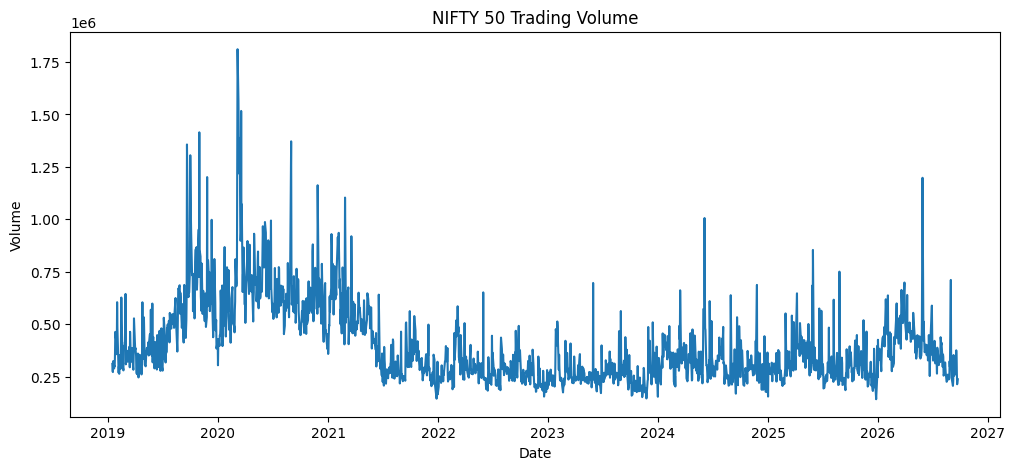

In [55]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data['Volume'])
plt.title('NIFTY 50 Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [56]:
volume_stats = data['Volume'].describe()
volume_stats

,Volume
count,1.873000e+03
mean,3.950403e+05
std,1.893812e+05
min,1.422000e+05
25%,2.611000e+05
50%,3.342000e+05
75%,4.870000e+05
max,1.811000e+06


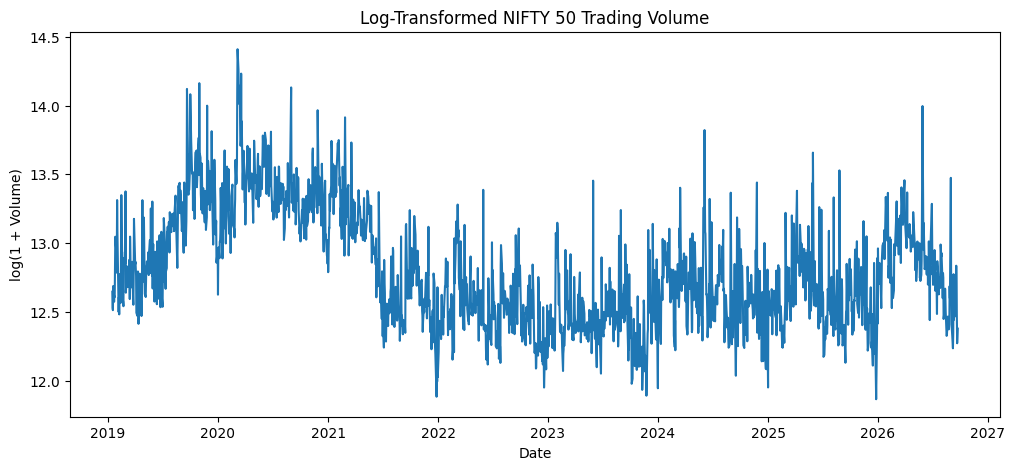

In [57]:
# A log transform helps stabilize the scale when volume varies substantially over time.
data['log_volume'] = np.log1p(data['Volume'])

plt.figure(figsize=(12, 5))
plt.plot(data.index, data['log_volume'])
plt.title('Log-Transformed NIFTY 50 Trading Volume')
plt.xlabel('Date')
plt.ylabel('log(1 + Volume)')
plt.show()

## 4. Chronological Train/Test Split

To avoid look-ahead bias, all observations from 2025 are kept as an out-of-sample test set. The model is trained only on observations available through 2024-12-31.

In [58]:
train = data.loc[data.index < '2025-01-01'].copy()
test = data.loc[(data.index >= '2025-01-01') & (data.index < '2026-01-01')].copy()

print('Training observations:', len(train))
print('2025 test observations:', len(test))

Training observations: 1448
2025 test observations: 247


## 5. Prepare Data for Prophet

Prophet expects columns named `ds` (timestamp) and `y` (target). The model is fit to log-transformed volume and predictions are transformed back to the original volume scale.

In [59]:
prophet_train = train.reset_index()[['Date', 'log_volume']].rename(
    columns={'Date': 'ds', 'log_volume': 'y'}
)
prophet_train.head()

Price,ds,y
0,2019-01-15,12.646586
1,2019-01-16,12.529970
2,2019-01-17,12.512457
3,2019-01-18,12.687884
4,2019-01-21,12.573493


## 6. Prophet Model

The model includes trend and yearly/weekly seasonal components. Daily seasonality is disabled because the target is observed on trading days rather than every calendar day.

In [60]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.90
)
model.fit(prophet_train)

In [61]:
future_2025 = pd.DataFrame({'ds': test.index})
forecast_2025 = model.predict(future_2025)

pred_2025 = pd.DataFrame({
    'Actual': test['Volume'].values,
    'Predicted': np.expm1(forecast_2025['yhat'].values),
    'Lower': np.expm1(forecast_2025['yhat_lower'].values),
    'Upper': np.expm1(forecast_2025['yhat_upper'].values)
}, index=test.index)

pred_2025.head()

,Actual,Predicted,Lower,Upper
Date,,,,
2025-01-01,154900,241887.160979,168620.324215,362897.759443
2025-01-02,283200,256826.435040,175282.977781,374593.915470
2025-01-03,312300,258241.973737,183269.179805,375857.337892
2025-01-06,278100,243648.793459,169974.632533,350068.468542
2025-01-07,262300,262070.433529,179884.036738,381967.413152


## 7. Out-of-Sample Evaluation

In [62]:
actual = pred_2025['Actual'].to_numpy()
predicted = pred_2025['Predicted'].to_numpy()

mae = np.mean(np.abs(actual - predicted))
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
mape = np.mean(np.abs((actual - predicted) / np.where(actual == 0, np.nan, actual))) * 100

metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [mae, rmse, mape]
})
metrics

,Metric,Value
0,MAE,84572.080462
1,RMSE,104157.090464
2,MAPE,29.388397


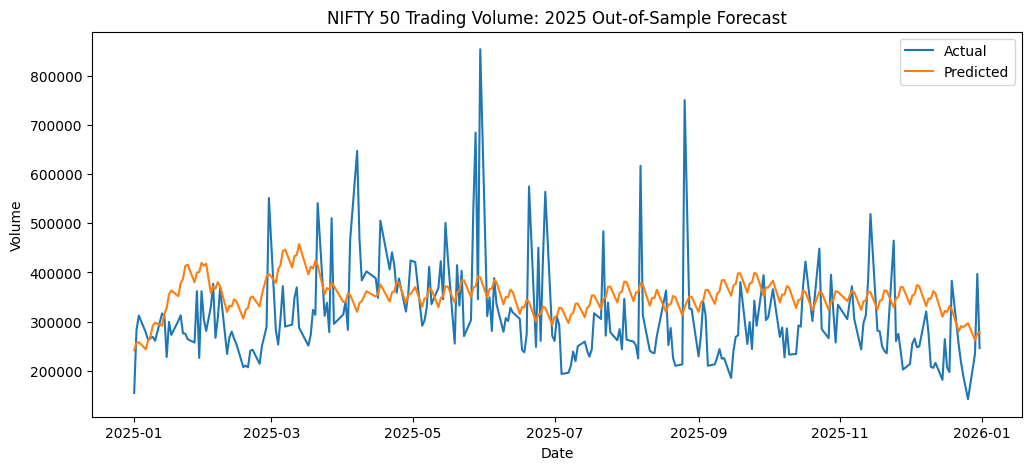

In [63]:
plt.figure(figsize=(12, 5))
plt.plot(pred_2025.index, pred_2025['Actual'], label='Actual')
plt.plot(pred_2025.index, pred_2025['Predicted'], label='Predicted')
plt.title('NIFTY 50 Trading Volume: 2025 Out-of-Sample Forecast')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

## 8. Refit on All Available Data

After evaluating the model on the 2025 holdout, the final model is refit using all currently available observations before generating the forward forecast.

In [65]:
final_train = data.reset_index()[['Date', 'log_volume']].rename(
    columns={'Date': 'ds', 'log_volume': 'y'}
)

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.90
)
final_model.fit(final_train)

## 9. 90-Trading-Day Forward Forecast

Only weekdays are generated and the next 90 dates after the latest observed date are used. This is a calendar approximation to trading days; market holidays are not removed automatically.

In [66]:
future_dates = pd.bdate_range(
    start=data.index.max() + pd.Timedelta(days=1),
    periods=90
)

future = pd.DataFrame({'ds': future_dates})
future_forecast = final_model.predict(future)

forecast_90 = pd.DataFrame({
    'Date': future_forecast['ds'],
    'Forecast': np.expm1(future_forecast['yhat']),
    'Lower_90': np.expm1(future_forecast['yhat_lower']),
    'Upper_90': np.expm1(future_forecast['yhat_upper'])
}).set_index('Date')

forecast_90.head()

,Forecast,Lower_90,Upper_90
Date,,,
2026-09-24,390895.587883,263140.610344,562077.229549
2026-09-25,391308.105346,272078.307385,577467.223895
2026-09-28,352820.334294,238488.712425,535785.718812
2026-09-29,373560.023085,257305.077359,545315.930637
2026-09-30,369983.862102,256720.552708,533787.776781


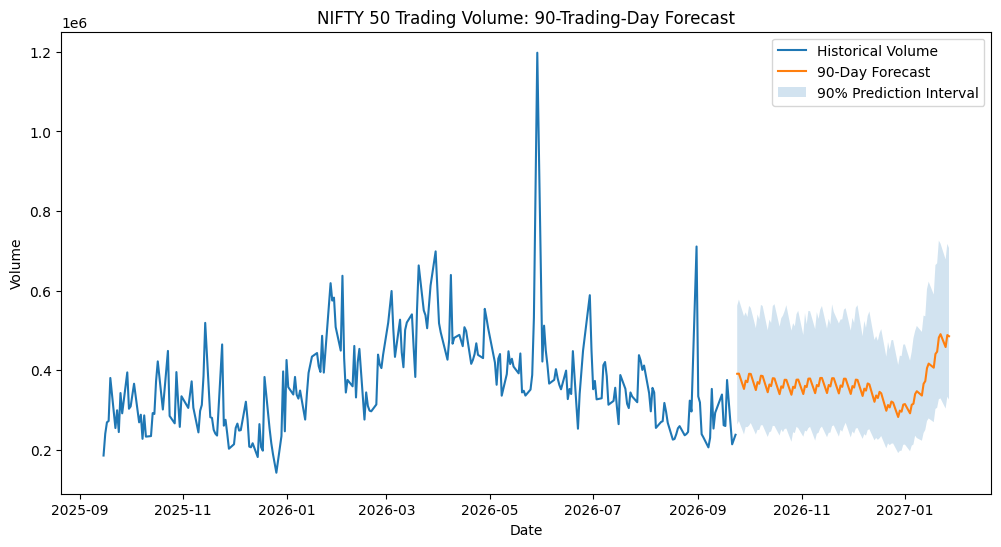

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(data.index[-250:], data['Volume'].tail(250), label='Historical Volume')
plt.plot(forecast_90.index, forecast_90['Forecast'], label='90-Day Forecast')
plt.fill_between(
    forecast_90.index,
    forecast_90['Lower_90'],
    forecast_90['Upper_90'],
    alpha=0.2,
    label='90% Prediction Interval'
)
plt.title('NIFTY 50 Trading Volume: 90-Trading-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

## 10. Key Results

In [69]:
print('----- 2025 Out-of-Sample Performance -----')
print(f'MAE: {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'MAPE: {mape:.2f}%')
print('\n----- Forward Forecast -----')
print(f'Forecast horizon: {len(forecast_90)} business days')
print(f'Forecast start: {forecast_90.index.min().date()}')
print(f'Forecast end: {forecast_90.index.max().date()}')

----- 2025 Out-of-Sample Performance -----
MAE: 84,572
RMSE: 104,157
MAPE: 29.39%

----- Forward Forecast -----
Forecast horizon: 90 business days
Forecast start: 2026-09-24
Forecast end: 2027-01-27
